Generates FigS8A

In [1]:
import numpy as np
import h5py
from scipy.io import loadmat
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from coding_model_fanofactor import *

# Zak et al. 2020 data

In [2]:
fname = '../data/Zak_2020/Glomerular_Matrix.mat'
# f = h5py.File(fname, 'r')
resp = loadmat(fname)['Glomerular_Matrix']

#### With the matrix of 228 glomerular responses to 32 odors, the goal is to show that each odor has a handful of "private" glomeruli that can ignore the effects of backgrounds.

In [3]:
resp.shape

(228, 32)

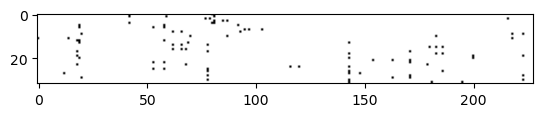

In [4]:
# find 3-glomerulus barcodes
k = 3
top_k = []
for odor in resp.T:
    top_k.append(np.argsort(odor)[-k:])
top_k = np.array(top_k)

# plt.plot(top_k[:, 0], top_k[:, 1], '.')
barcode = np.zeros(resp.T.shape)
for odor_idx in range(len(barcode)):
    barcode[odor_idx][top_k[odor_idx]] = 1
plt.figure()
plt.imshow(barcode, cmap='Grays')

In [5]:
import numpy as np
from collections import Counter

# 1. sort each pair so smaller‐first
normalized = [tuple(sorted(pair)) for pair in top_k]

# 2. count with Counter
counts = Counter(normalized)

# now counts[(a,b)] is the number of times the unordered pair {a,b} appeared
# for pair, cnt in counts.items():
#     print(f"{pair}: {cnt}")


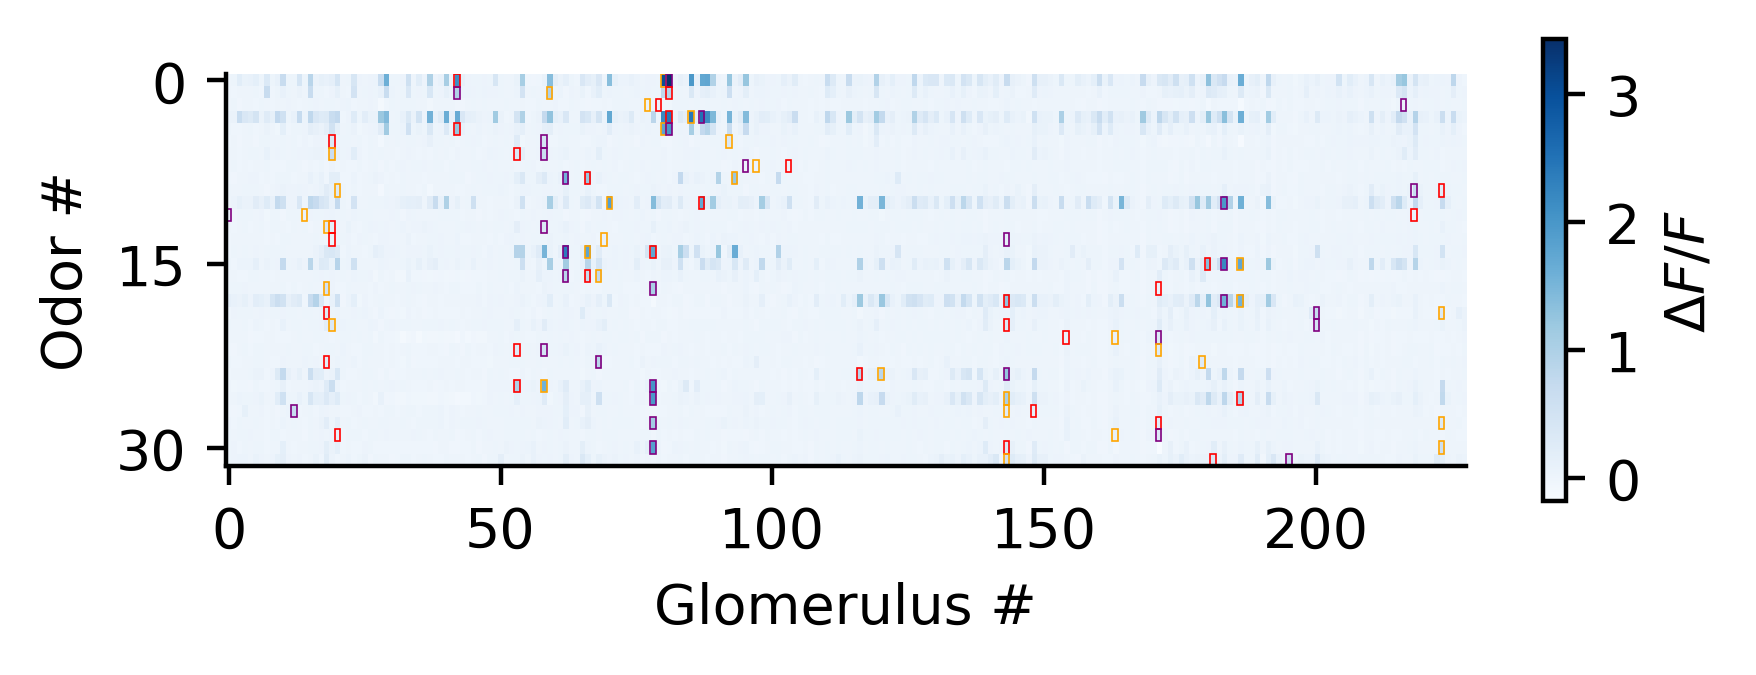

In [6]:
fig, ax = plt.subplots(figsize=(5,1.5), dpi=400)
cax = ax.imshow(resp.T, cmap='Blues', aspect=2.25)
# plt.imshow(resp.T, cmap='Blues') #, vmin=0, vmax=2.0)
fig.colorbar(mappable=cax, label='$\Delta F/F$')
ax.set_ylabel('Odor #')
ax.set_xlabel('Glomerulus #')
ax.set_yticks(np.arange(0, 32, 15))

# Coordinates to highlight (row, column)
highlight_coords = top_k
for odor_idx, top_gloms in enumerate(top_k):
    for kth_most, glom in enumerate(top_gloms):
        rect = patches.Rectangle(
            (glom - 0.5, odor_idx - 0.5),  # bottom-left corner in data coords
            1,                   # full width of one cell
            1,                   # full height of one cell
            linewidth=0.3,
            edgecolor=['r', 'orange', 'purple'][kth_most],
            facecolor='none',
            transform=ax.transData
        )
        ax.add_patch(rect)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


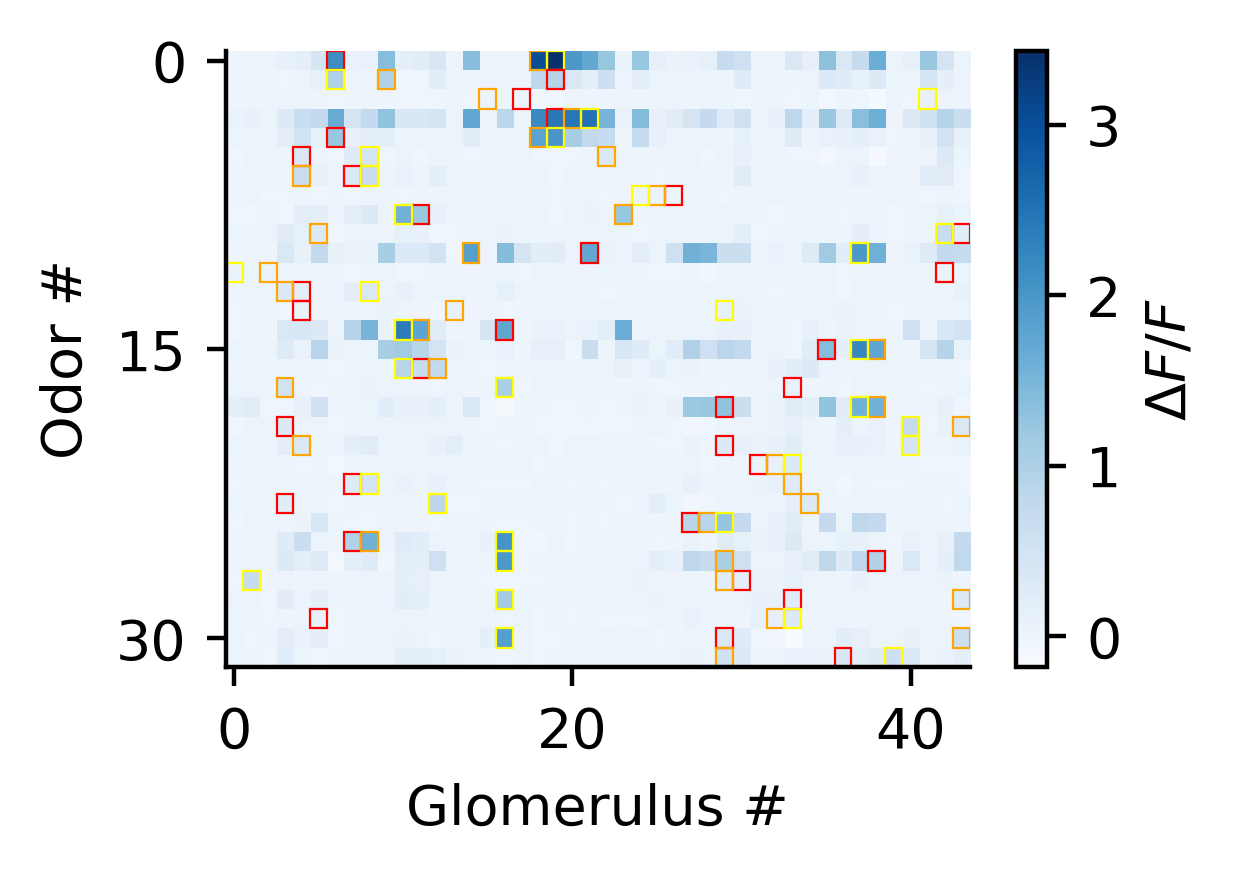

In [7]:
# --- 1) find which glomerulus‐columns actually get boxed ---
all_gloms = sorted({g for tops in top_k for g in tops})
# e.g. [0, 2, 5, 7, 9]

# --- 2) slice resp to only those gloms (rows of resp) ---
# filtered_resp: shape (len(all_gloms), n_odors)
filtered_resp = resp[all_gloms, :]

# --- 3) build a list of (odor_idx, new_glom_idx, rank) for drawing boxes ---
new_boxes = []
for odor_idx, tops in enumerate(top_k):
    for rank, old_g in enumerate(tops):
        if old_g in all_gloms:
            new_g = all_gloms.index(old_g)
            new_boxes.append((odor_idx, new_g, rank))

# --- 4) plot the trimmed heatmap & remapped boxes ---
fig, ax = plt.subplots(figsize=(3, 2), dpi=400)

# transpose so x→gloms, y→odors
cax = ax.imshow(filtered_resp.T, 
                cmap='Blues', 
                aspect='auto', 
                origin='upper')

fig.colorbar(cax, label='$\\Delta F/F$')
ax.set_xlabel('Glomerulus #')
ax.set_ylabel('Odor #')
ax.set_yticks(np.arange(0, resp.shape[1], 15))

# draw each box at (x=new_glom, y=odor)
colors = ['red','orange','yellow']
for odor_idx, new_g, rank in new_boxes:
    rect = patches.Rectangle(
        (new_g - 0.5, odor_idx - 0.5),  # x, y in data coords
        1, 1,                           # full cell size
        linewidth=0.4,
        edgecolor=colors[rank % len(colors)],
        facecolor='none',
        transform=ax.transData
    )
    ax.add_patch(rect)

# clean up spines & ticks
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
plt.savefig('../figures/manuscript/glomerular_barcode.svg', dpi=600, bbox_inches='tight')
plt.savefig('../figures/manuscript/glomerular_barcode.png', dpi=600, bbox_inches='tight')

#### compare the population sparsity of the data with the model

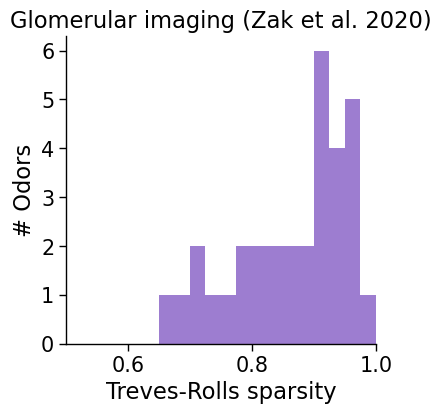

In [8]:
from coding_model_fanofactor import *


sparsity = population_sparsity(np.maximum(resp, 0))
# sparsity = PR_sparsity(np.maximum(resp, 0))
# sparsity = PR_sparsity(resp)
sns.set_context("paper", font_scale=1.7)  # "talk", "notebook", "paper", "poster"
plt.figure(figsize=(4,4))
plt.hist(sparsity, bins=np.arange(0.5, 1.025, 0.025),color="#9d7dd0")
plt.xlabel('Treves-Rolls sparsity')
plt.ylabel('# Odors')
plt.title('Glomerular imaging (Zak et al. 2020)')
plt.xlim(0.5, 1.)
sns.despine()
# plt.savefig('../figures/manuscript/glomerular_data_sparsity.svg', dpi=600, bbox_inches='tight')
# plt.savefig('../figures/manuscript/glomerular_data_sparsity.png', dpi=600, bbox_inches='tight')




## plot model and data sparsities all together

In [9]:
from scipy.io import loadmat
burton = loadmat('../data/Burton_2022/Fig1figsupp3source data 1_figS3_data.mat')
burton_sparsities = burton['popsparseness_dF_F']

# burton_sorted_sparsity_list = []
# burton_cum_frac_list = []
# for ob in burton_sparsities.T:
#     burton_sorted_sparsity = sorted(ob, reverse=False)
#     burton_cum_frac = np.cumsum(burton_sorted_sparsity) / np.sum(burton_sorted_sparsity)
burton_sorted_sparsity = sorted(burton_sparsities.flatten()[~np.isnan(burton_sparsities.flatten())], reverse=False)
burton_cum_frac = np.cumsum(burton_sorted_sparsity) / np.sum(burton_sorted_sparsity)

colors = [
    "#9d7dd0",
    "#5e78dd",    
    "#86d6d3",
    "#7dcc66",
    "#acd05b",
    "#efd962",
    "#dc9c4f",
    "#bd6f6d",
    "#c37ab4",
]
sns.set_palette(colors)


[0.00031623 0.00032833 0.00034089 0.00035393 0.00036747 0.00038152
 0.00039612 0.00041127 0.00042701 0.00044334 0.0004603  0.00047791
 0.00049619 0.00051518 0.00053489 0.00055535 0.00057659 0.00059865
 0.00062155 0.00064533 0.00067002 0.00069565 0.00072226 0.00074989
 0.00077858 0.00080837 0.00083929 0.0008714  0.00090474 0.00093935
 0.00097528 0.00101259 0.00105133 0.00109155 0.00113331 0.00117666
 0.00122168 0.00126841 0.00131694 0.00136732 0.00141963 0.00147393
 0.00153032 0.00158886 0.00164965 0.00171276 0.00177828 0.00184631
 0.00191694 0.00199027 0.00206641 0.00214547 0.00222754 0.00231276
 0.00240124 0.0024931  0.00258847 0.0026875  0.00279031 0.00289705
 0.00300788 0.00312295 0.00324242 0.00336646 0.00349525 0.00362896
 0.00376779 0.00391193 0.00406159 0.00421697 0.00437829 0.00454578
 0.00471969 0.00490024 0.0050877  0.00528234 0.00548442 0.00569423
 0.00591206 0.00613823 0.00637306 0.00661686 0.00687    0.00713281
 0.00740568 0.00768899 0.00798314 0.00828854 0.00860563 0.0089

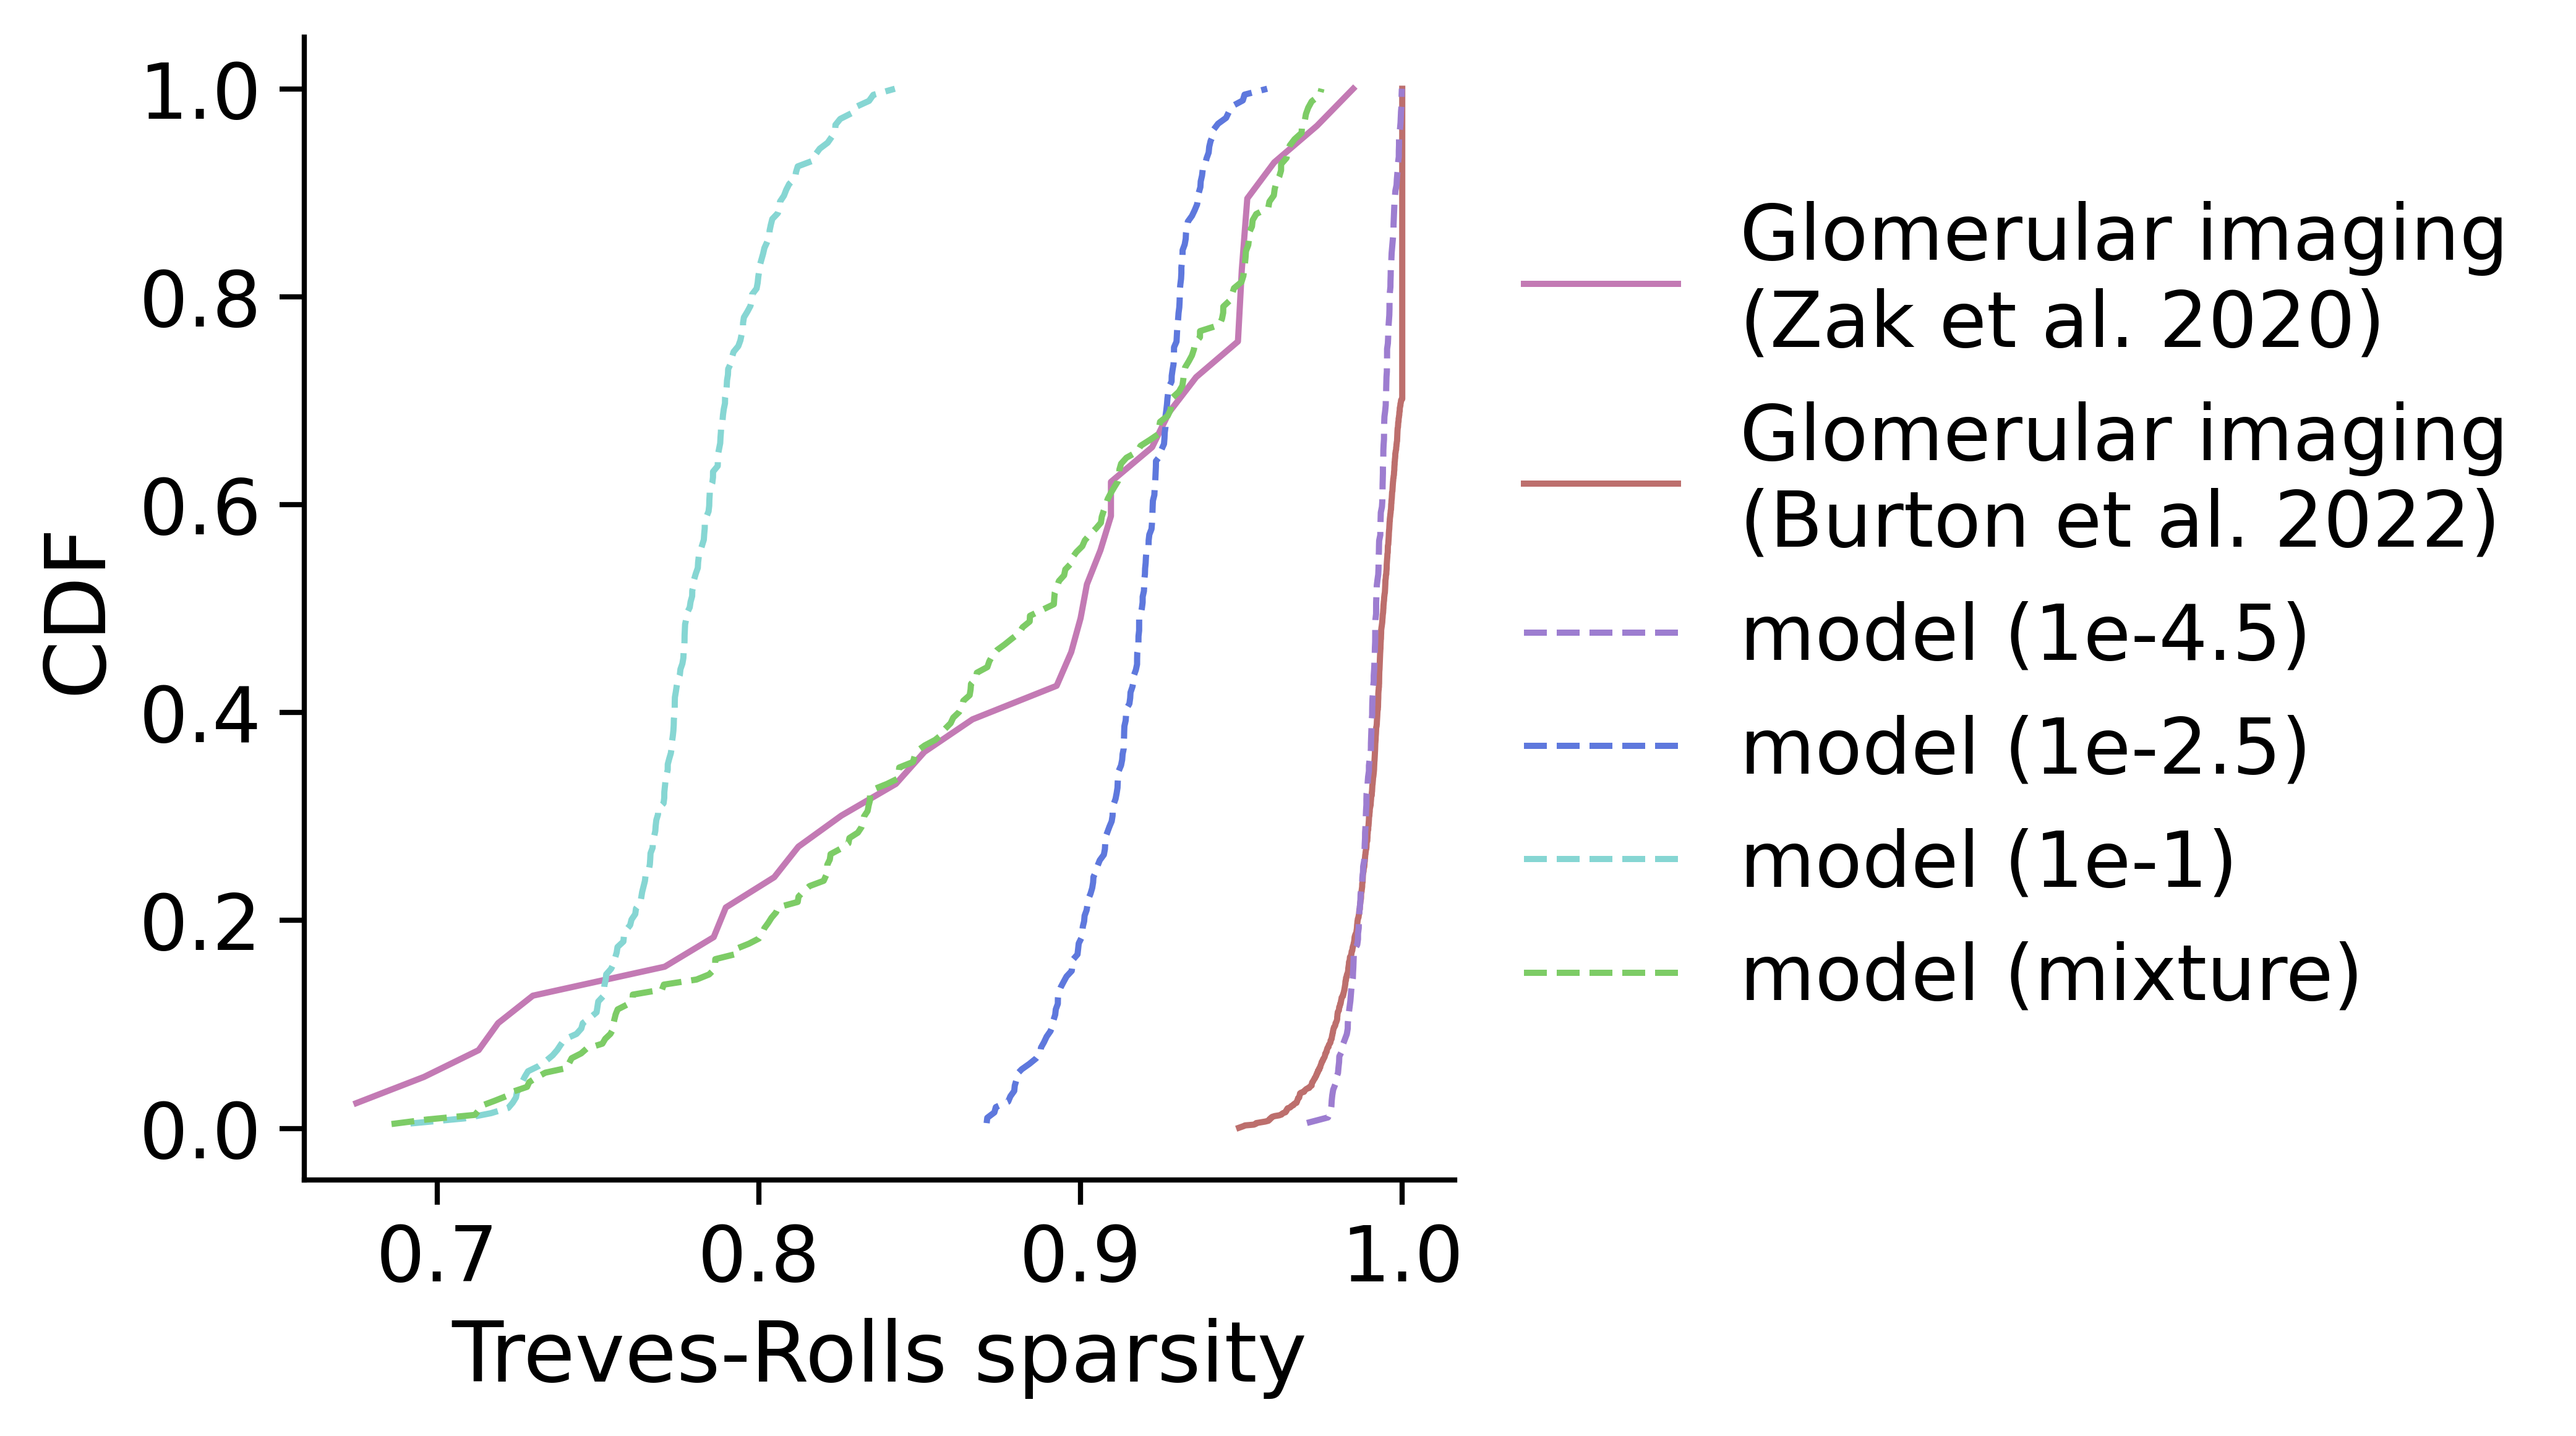

In [22]:
from coding_model_fanofactor import *

N = 20
rho = 0.5
rng = np.random.default_rng(42)
# compute population sparsity for 32 single odors
conc = 3.2e-3 #1e-3 # 1e0 # 1e-3 is weak, 1e0 is strong
n_glom_shown = 228
b = 185  # number of single odors/channels
sns.set_context("paper", font_scale=1.7)  # "talk", "notebook", "paper", "poster"

def glom_model_sparsity(conc, n_glom_shown=228, b=185, concs=None):
    if concs is None:
        concs = np.eye(b) * conc
    conc_tensor = tensorize_concs(concs, n_samp=concs.shape[0], b=concs.shape[1], N=N)

    rng = np.random.default_rng(42)
    lnkappa = rng.standard_normal((b, N, N))
    lneta = rng.standard_normal((b, N, N))
    lneta = rho * lnkappa + np.sqrt(1 - rho * rho) * lneta
    lnkappa = -4 * lnkappa
    kappa = np.exp(lnkappa)
    eta = np.exp(lneta)

    inv_kappa = 1.0 / kappa
    F_max = 10.0
    hill_n = 4

    r = compute_activity_vec(
    conc_tensor,
    kappa,
    eta,
    F_max=F_max,
    n=hill_n,
    sigma=0.4 / np.sqrt(5), # average over 5 trials
    inv_kappa=inv_kappa,
    fano_factor_one=True,
    fano_factor=1.0,
    ).reshape(concs.shape[0], -1)[:, :n_glom_shown]

    r = np.maximum(r, 0) # non-negative
    model_sorted_sparsity = sorted(population_sparsity(r.T), reverse=False)
    # print(len(model_sorted_sparsity))
    model_cum_frac = np.cumsum(model_sorted_sparsity) / np.sum(model_sorted_sparsity)
    return model_sorted_sparsity, model_cum_frac

weak_sparsity, weak_cdf = glom_model_sparsity(3.2e-3)
very_weak_sparsity, very_weak_cdf = glom_model_sparsity(10**(-4.5))
strong_sparsity, strong_cdf = glom_model_sparsity(0.1)
mixture_sparsity, mixture_cdf = glom_model_sparsity(conc=0, concs=np.diag(np.logspace(-3.5, -0.5, b)))

print(np.logspace(-3.5, -0.5, b))


plt.figure(figsize=(4,4), dpi=600)
sorted_sparsity = np.sort(sparsity)
cum_frac = np.cumsum(sorted_sparsity) / sorted_sparsity.sum()

plt.plot(sorted_sparsity, cum_frac, color='C8', label="Glomerular imaging\n(Zak et al. 2020)")
plt.plot(burton_sorted_sparsity, burton_cum_frac, color='C7', label="Glomerular imaging\n(Burton et al. 2022)")
plt.plot(very_weak_sparsity, very_weak_cdf, linestyle='--', label="model (1e-4.5)")
plt.plot(weak_sparsity, weak_cdf, linestyle='--', label="model (1e-2.5)")
plt.plot(strong_sparsity, strong_cdf, linestyle='--', label="model (1e-1)")
plt.plot(mixture_sparsity, mixture_cdf, linestyle='--', label="model (mixture)")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
plt.xlabel('Treves-Rolls sparsity')
plt.ylabel('CDF')
# plt.title('Fano factor = 1 noise')
# plt.xlim(0.5, 1.)
sns.despine()
plt.savefig('../figures/manuscript/glomerular_data_sparsity_cdf.svg', dpi=600, bbox_inches='tight')
plt.savefig('../figures/manuscript/glomerular_data_sparsity_cdf.png', dpi=600, bbox_inches='tight')